In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# DATA LOADING #

In [2]:
import numpy as np
import pandas as pd
import re
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")


In [3]:
train_df=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_df= pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")


In [4]:
train_df.shape

(198000, 15)

In [5]:
train_df.head(5)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [6]:
test_df.shape

(102000, 14)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [8]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [9]:
train_df['label'].value_counts()



label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Label is our target column.we have four types of category in label column.0 defines the normal comment,1 defines a slightly offensive comment,2 defines offensive comment and class 3 defines a proper negative comment.

In [10]:
train_df.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

# Data Visualisation #

Text(0, 0.5, 'Count')

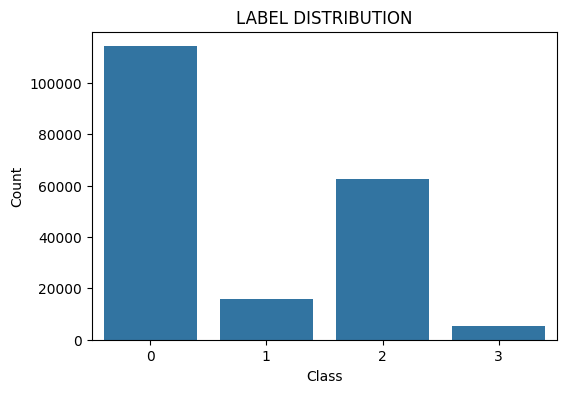

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='label',data=train_df)
plt.title("LABEL DISTRIBUTION")
plt.xlabel("Class")
plt.ylabel("Count")

1.)The dataset is very imbalanced.<br>
2.)some classes have more samples than others.<br>
3.)class 0 dominates the dataset means most of the comments belong to this category.<br>
4.)class 2 is the second largest class but still the difference between the class 0 and class 2 is quite big.<br>
5.)class 3 and class 1 has very few samples.<br>
6.)Because of this imbalance, the model may become biased towards predicting majority classes(class 0 and maybe class 2).minority classes like class 3 and 1 are harder to predict.<br>
7.)And because of all these reaons we used F1 score for evaluation.1. 

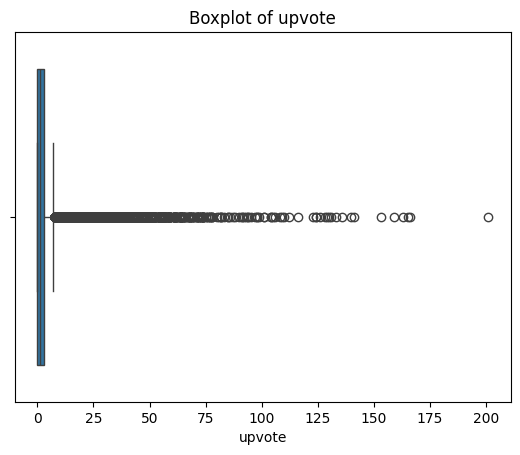

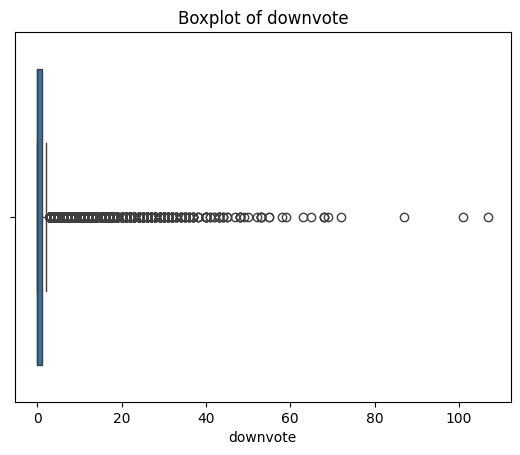

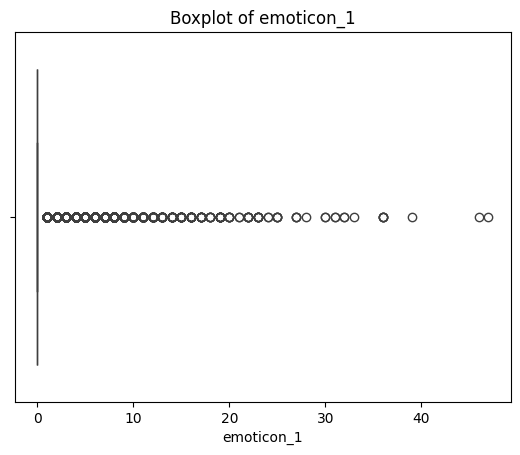

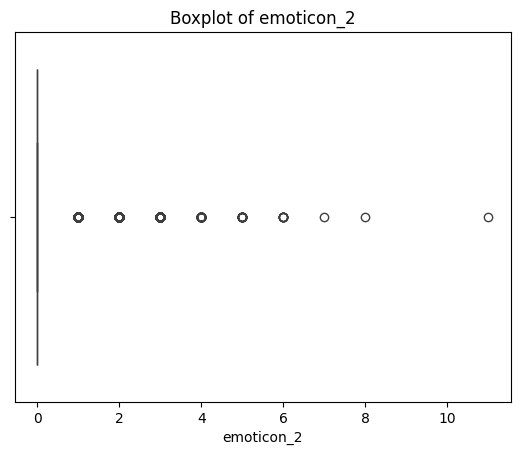

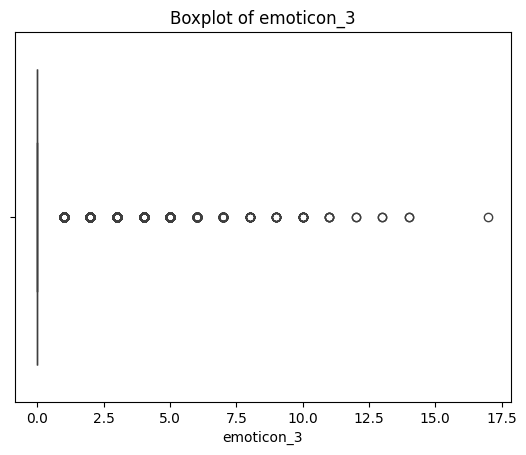

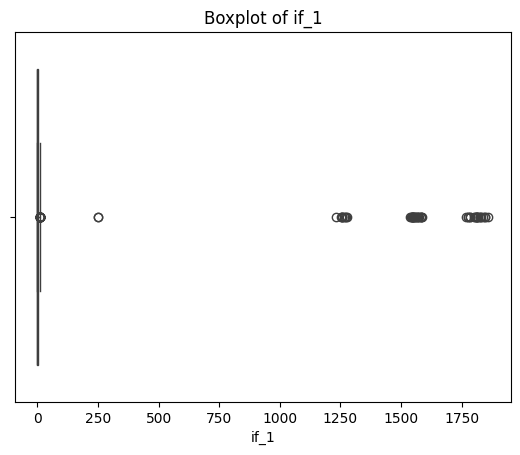

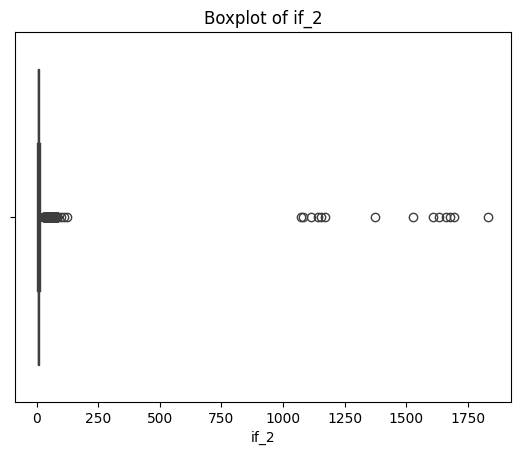

In [12]:
num_cols=['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']

for col in num_cols:
    plt.figure()
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# handling outliers

In [13]:
def outliers_iqr(df, column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=df[(df[column]<lower)|(df[column]>upper)]
    
    print(f"{column}: {len(outliers)} outliers")
    
    return outliers

In [14]:
for col in num_cols:
    outliers_iqr(train_df, col)

upvote: 17304 outliers
downvote: 15173 outliers
emoticon_1: 28922 outliers
emoticon_2: 8109 outliers
emoticon_3: 17165 outliers
if_1: 85 outliers
if_2: 3930 outliers


In [15]:
def cap_outliers(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    
    df[column]=df[column].clip(lower,upper)
    
    return df

In [16]:
for col in num_cols:
    train_df=cap_outliers(train_df,col)
    outliers_iqr(train_df,col)

upvote: 0 outliers
downvote: 0 outliers
emoticon_1: 0 outliers
emoticon_2: 0 outliers
emoticon_3: 0 outliers
if_1: 0 outliers
if_2: 0 outliers


## correlation matrix

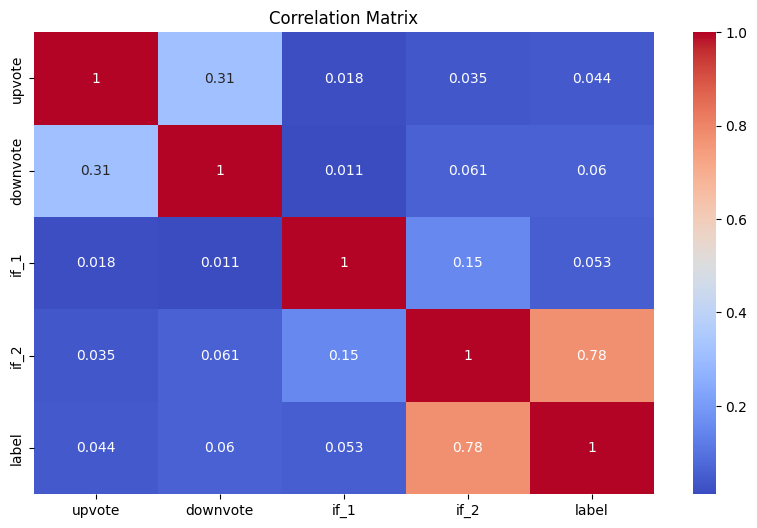

In [17]:
num_cols =['upvote','downvote','if_1', 'if_2','label']
corr_matrix = train_df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The strongest relationship among all numerical columns is between if_2 and label(0.78).


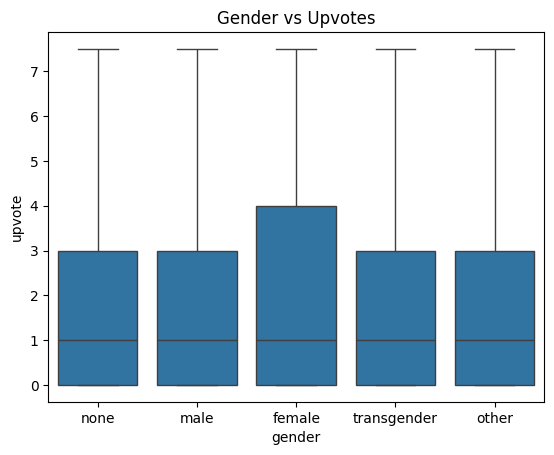

In [18]:
sns.boxplot(x='gender', y='upvote', data=train_df)
plt.title("Gender vs Upvotes")
plt.show()

# Data Cleaning #

In [19]:
df=train_df.copy()

In [20]:
df=df.dropna(subset=['comment'])
df=df.drop(columns=['race','religion','gender'])
df['disability']=df['disability'].astype(int)

In [21]:
df=df.drop_duplicates(subset=['comment'])


insights for data cleaning part<br>
1.) we have removed the row of the dataset where column(comment) has missing value.<br>
2.)we have dropped the columns race,religion,gender because of two reasons:<br>
2.1) These columns has 145423 missing values means too many NaNs and that is not useful for data.<br>
2.2) Even if we try to fill those missing columns with "unknown" it will add noise.<br>
3.)Machine learning models do not handle True/False values effectively, so we convert them into numerical values (1 and 0). This process is called binary encoding.



## Text cleaning

In [22]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'http\S+|www\S+',' ',text)   
    text=re.sub(r'[^a-z\s]',' ',text)        
    text=" ".join(text.split())
    return text

df['comment_clean']=df['comment'].apply(clean_text)


# Feature Engineering #

In [23]:
df['vote_diff']=df['upvote']-df['downvote']#postive means liked and negative means disliked
df['vote_sum']=df['upvote']+df['downvote']#defines popularity 


In [24]:
df['comment_length'] = df['comment'].str.len()
df['word_count'] = df['comment'].str.count(r'\S+')
df['avg_word_length'] = df['comment_length'] / (df['word_count'] + 1)


We created these features to convert text into numbers so the model can understand the length, word count, and writing style of comments.

In [25]:
df['total_emoticons']=(
    df['emoticon_1']+
    df['emoticon_2']+
    df['emoticon_3']
)

df['emoticon_ratio']=df['total_emoticons']/(df['word_count']+1)# high ratio means strong emotion and low ratio means neutral response


# Feature Selection #

In [26]:
num_features=[
    'emoticon_1','emoticon_2','emoticon_3',
    'upvote','downvote',
    'if_1','if_2',
    'disability',
    'vote_diff','vote_sum',
    'comment_length','word_count',
    'avg_word_length','emoticon_ratio'
]


# Train Validation Split #

In [27]:
X=df[['comment_clean']+num_features]
y=df['label']

In [28]:
X_train,X_val,y_train,y_val=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

# Preprocessing Pipeline #

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(
            max_features=8000,
            ngram_range=(1, 2),
            min_df=5
        ), 'comment_clean'),
        ('num', StandardScaler(), num_features)
    ]
)


# SGD #

In [30]:
sgd_model=Pipeline([
    ("preprocess",preprocessor),
    ("clf",SGDClassifier(
        loss="log_loss",
        max_iter=2000,
        alpha=0.00005,
        class_weight="balanced",
        random_state=42
    ))
])

sgd_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=8000,
                                                                  min_df=5,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'comment_clean'),
                                                 ('num', StandardScaler(),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'upvote',
                                                   'downvote', 'if_1', 'if_2',
                                                   'disability', 'vote_diff',
                                                   'vote_sum', 'comment_length',
                                                   'word_count',
                                                   'avg_word_length',
                                                   'emoticon_ratio'])])),
                ('clf',
                 SGDClassifier(alpha=5e-05, class_weight='balanced',
                               loss='log_loss', max_iter=2000,
                               random_state=42))])

# Logistic Regression #

In [31]:
lr_model=Pipeline([
    ("preprocess",preprocessor),
    ("clf",LogisticRegression(
        max_iter=3000,
        C=3,
        class_weight="balanced",
        n_jobs=-1
    ))
])


In [32]:
param_grid = {
    'preprocess__text__max_features': [8000, 12000, 20000],
    'preprocess__text__ngram_range': [(1,1), (1,2)],
    'preprocess__text__min_df': [2, 3, 5],
    'preprocess__text__max_df': [0.85, 0.9, 0.95],

    'clf__C': [0.5, 1, 3, 5, 10],
    'clf__solver': ['liblinear', 'saga']
}

random_search = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_grid,
    n_iter=12,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/li

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('text',
                                                                               TfidfVectorizer(max_features=8000,
                                                                                               min_df=5,
                                                                                               ngram_range=(1,
                                                                                                            2)),
                                                                               'comment_clean'),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               ['emoticon_1',
                                                                                'emoticon_2',
                                                                                'emoticon_3',
                                                                                'upvote',
                                                                                'downvote',
                                                                                'if_1',
                                                                                'if_2',
                                                                                'disability',
                                                                                'vote_diff',
                                                                                'vote_sum',
                                                                                'comment_length',
                                                                                'word_count',
                                                                                'av...
                                                                 max_iter=3000,
                                                                 n_jobs=-1))]),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'clf__C': [0.5, 1, 3, 5, 10],
                                        'clf__solver': ['liblinear', 'saga'],
                                        'preprocess__text__max_df': [0.85, 0.9,
                                                                     0.95],
                                        'preprocess__text__max_features': [8000,
                                                                           12000,
                                                                           20000],
                                        'preprocess__text__min_df': [2, 3, 5],
                                        'preprocess__text__ngram_range': [(1,
                                                                           1),
                                                                          (1,
                                                                           2)]},
                   random_state=42, scoring='f1_weighted', verbose=2)

In [33]:
best_lr = random_search.best_estimator_

print(random_search.best_params_)

{'preprocess__text__ngram_range': (1, 1), 'preprocess__text__min_df': 2, 'preprocess__text__max_features': 8000, 'preprocess__text__max_df': 0.9, 'clf__solver': 'liblinear', 'clf__C': 5}


# SVM #

In [34]:
svm_model=Pipeline([
    ("preprocess",preprocessor),
    ("clf",LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=3000
    ))
])

svm_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=8000,
                                                                  min_df=5,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'comment_clean'),
                                                 ('num', StandardScaler(),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'upvote',
                                                   'downvote', 'if_1', 'if_2',
                                                   'disability', 'vote_diff',
                                                   'vote_sum', 'comment_length',
                                                   'word_count',
                                                   'avg_word_length',
                                                   'emoticon_ratio'])])),
                ('clf', LinearSVC(class_weight='balanced', max_iter=3000))])

# Boosting (LightGBM) #

In [35]:
lgb_model=Pipeline([
    
("preprocess",preprocessor),

("clf",LGBMClassifier(
    n_estimators=700,
    learning_rate=0.05,
    num_leaves=80,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42))
])

lgb_model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 7.900969 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1106341
[LightGBM] [Info] Number of data points in the train set: 158273, number of used features: 8010
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[CV] END clf__C=0.5, clf__solver=saga, preprocess__text__max_df=0.9, preprocess__text__max_features=8000, preprocess__text__min_df=2, preprocess__text__ngram_range=(1, 2); total time=13.1min
[CV] END clf__C=0.5, clf__solver=saga, preprocess__text__max_df=0.9, preprocess__text__max_features=20000, preprocess__text__min_df=3, preprocess__text__ngram_range=(1, 1); total time=10.3min
[CV] END clf__C=0.5, clf__solver=saga, preprocess__text__max_df=0.9, preprocess__text__max_features=20000,

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=8000,
                                                                  min_df=5,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'comment_clean'),
                                                 ('num', StandardScaler(),
                                                  ['emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'upvote',
                                                   'downvote', 'if_1', 'if_2',
                                                   'disability', 'vote_diff',
                                                   'vote_sum', 'comment_length',
                                                   'word_count',
                                                   'avg_word_length',
                                                   'emoticon_ratio'])])),
                ('clf',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
                                learning_rate=0.05, n_estimators=700,
                                num_leaves=80, random_state=42,
                                subsample=0.8))])

# Ensemble

In [36]:
ensemble=VotingClassifier(
    estimators=[
        ("sgd",sgd_model),
        ("lr",best_lr),
        ("lgb",lgb_model)
    ],
    voting="soft",
    weights=[3,2,2],
    n_jobs=-1
)

ensemble.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


VotingClassifier(estimators=[('sgd',
                              Pipeline(steps=[('preprocess',
                                               ColumnTransformer(transformers=[('text',
                                                                                TfidfVectorizer(max_features=8000,
                                                                                                min_df=5,
                                                                                                ngram_range=(1,
                                                                                                             2)),
                                                                                'comment_clean'),
                                                                               ('num',
                                                                                StandardScaler(),
                                                                                ['emoticon_1',
                                                                                 'emoticon_2',
                                                                                 'emoticon_3',
                                                                                 'upvote',
                                                                                 'downvote',
                                                                                 'if_1',
                                                                                 'if_2',
                                                                                 'disability',
                                                                                 'vote_diff',
                                                                                 'vote_sum',
                                                                                 'comment_length',
                                                                                 'word_count',
                                                                                 '...
                                                                                 'emoticon_2',
                                                                                 'emoticon_3',
                                                                                 'upvote',
                                                                                 'downvote',
                                                                                 'if_1',
                                                                                 'if_2',
                                                                                 'disability',
                                                                                 'vote_diff',
                                                                                 'vote_sum',
                                                                                 'comment_length',
                                                                                 'word_count',
                                                                                 'avg_word_length',
                                                                                 'emoticon_ratio'])])),
                                              ('clf',
                                               LGBMClassifier(class_weight='balanced',
                                                              colsample_bytree=0.8,
                                                              learning_rate=0.05,
                                                              n_estimators=700,
                                                              num_leaves=80,
                                                              random_state=42,
                                                              subsample=0.8))]))],
                 

# model comparison

In [37]:
models ={
    "Tuned Logistic Regression":best_lr,
    "SGD": sgd_model,
    "SVM":svm_model,
    "LightGBM":lgb_model,
    "Voting Ensemble":ensemble
}
results = []

for name, model in models.items():
    preds = model.predict(X_val)
    acc = accuracy_score(y_val,preds)
    f1 = f1_score(y_val, preds,average='weighted')
    results.append([name,acc,f1])

comparison_df=pd.DataFrame(results,columns=["Model","Accuracy","F1 Score"])
comparison_df=comparison_df.sort_values(by="F1 Score",ascending=False)
comparison_df

,Model,Accuracy,F1 Score
3,LightGBM,0.907832,0.909680
4,Voting Ensemble,0.908691,0.909495
0,Tuned Logistic Regression,0.903485,0.905864
2,SVM,0.898178,0.901004
1,SGD,0.889156,0.889420


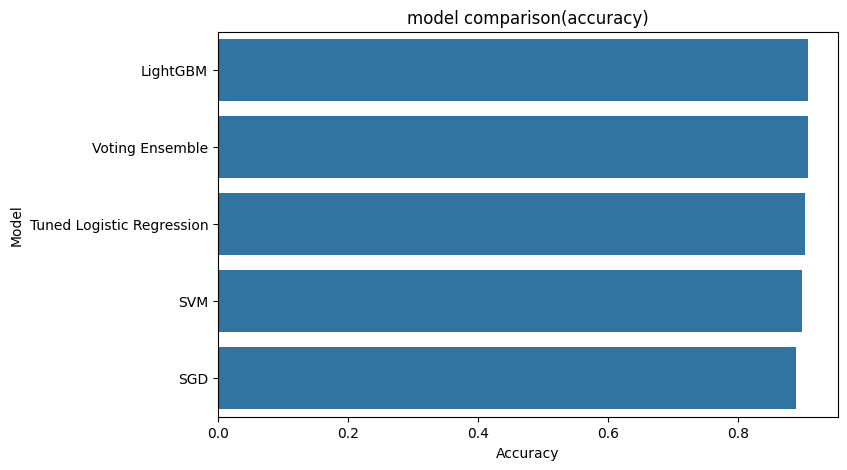

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(x="Accuracy",y="Model",data=comparison_df)
plt.title("model comparison(accuracy)")
plt.show()

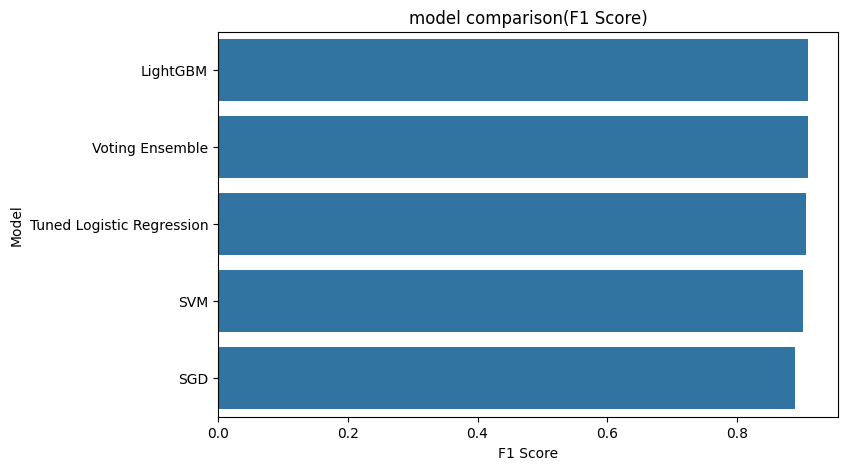

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(x="F1 Score",y="Model",data=comparison_df)
plt.title("model comparison(F1 Score)")
plt.show()

In [40]:
y_pred=ensemble.predict(X_val)
print(classification_report(y_val, y_pred))
print("Accuracy:",accuracy_score(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22814
           1       0.75      0.80      0.77      3183
           2       0.86      0.89      0.88     12480
           3       0.66      0.63      0.65      1092

    accuracy                           0.91     39569
   macro avg       0.81      0.82      0.81     39569
weighted avg       0.91      0.91      0.91     39569

Accuracy: 0.9086911471101115


# Confusion Matrix

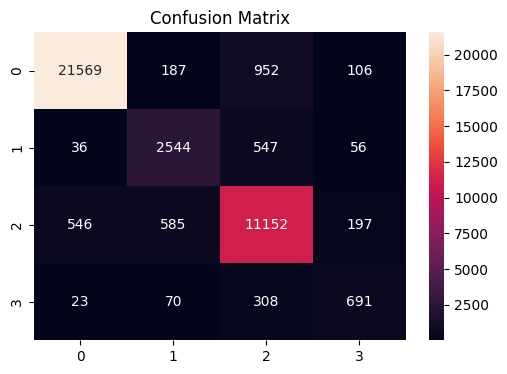

In [41]:
cm =confusion_matrix(y_val,y_pred) 
plt.figure(figsize=(6,4)) 
sns.heatmap(cm,annot=True,fmt='d') 
plt.title("Confusion Matrix") 
plt.show()

# Test Predictions

In [42]:
test_df=test_df.copy()

test_df['comment_clean']=test_df['comment'].apply(clean_text)


In [43]:
test_df['vote_diff']=test_df['upvote']-test_df['downvote']
test_df['vote_sum']=test_df['upvote']+test_df['downvote']

test_df['comment_length']=test_df['comment'].str.len()
test_df['word_count']=test_df['comment'].str.split().str.len()
test_df['avg_word_length']=(
    test_df['comment_length']/ (test_df['word_count'] +1)
)

test_df['total_emoticons']= (
    test_df['emoticon_1']+
    test_df['emoticon_2']+
    test_df['emoticon_3']
)

test_df['emoticon_ratio']=(
    test_df['total_emoticons']/(test_df['word_count']+1)
)
X_test=test_df[['comment_clean']+num_features]




In [44]:
def get_iqr_bounds(df, column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3- Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    return lower,upper

iqr_bounds = {}

for col in num_cols:
    lower, upper=get_iqr_bounds(train_df,col)
    iqr_bounds[col]=(lower, upper)

In [45]:
def cap_using_bounds(df, column, bounds):
    lower, upper = bounds
    df[column] = df[column].clip(lower, upper)
    return df

for col in num_cols:
    train_df = cap_using_bounds(train_df, col, iqr_bounds[col])

In [46]:
y_test_pred=ensemble.predict(X_test)


# Submission

In [47]:
submission=pd.DataFrame({
    "ID": sample_df["ID"],
    "label": y_test_pred
})

submission.to_csv("submission.csv",index=False)
print("submission.csv created")
submission.head()

submission.csv created


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
